In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("data\\airpollution.csv")

In [3]:
df

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good
...,...,...,...,...,...,...,...,...,...,...
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good


In [4]:
df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [5]:
df.shape

(5000, 10)

In [6]:
df.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   str    
dtypes: float64(8), int64(1), str(1)
memory usage: 390.8 KB


In [8]:
df.isnull().sum()

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64

In [9]:
df.columns

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density', 'Air Quality'],
      dtype='str')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

Temperature                      362
Humidity                         723
PM2.5                            815
PM10                             955
NO2                              445
SO2                              348
CO                               265
Proximity_to_Industrial_Areas    179
Population_Density               683
Air Quality                        4
dtype: int64

## All columns are numerical values

In [12]:
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

In [13]:
numeric_cols

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density'],
      dtype='str')

## distribution plots for numeric columns

 ## Distribution plots help in prediction by showing:

Which features need transformation (skewness).

Which features may need outlier handling.

The relative predictive strength of pollutants vs weather.

Class imbalance in the target variable.

What modeling approach might work best.

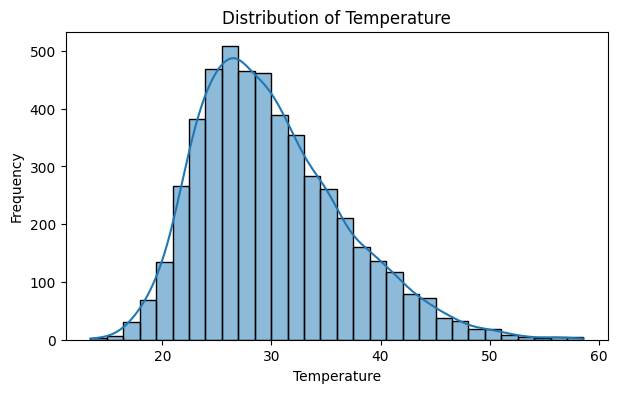

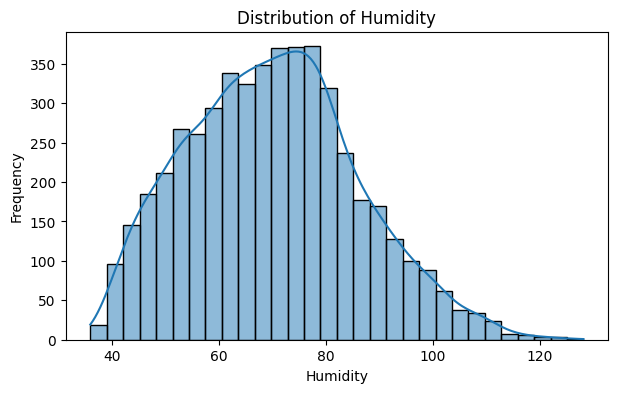

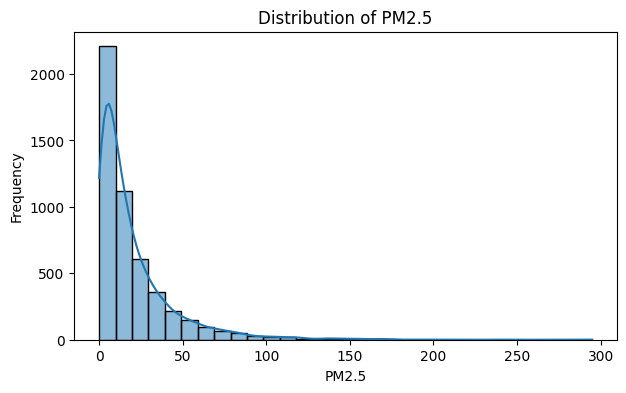

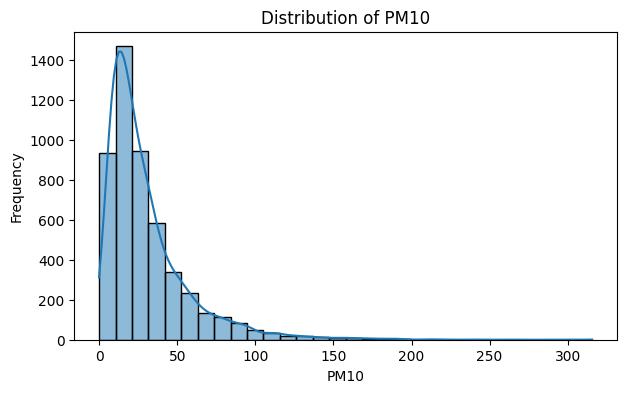

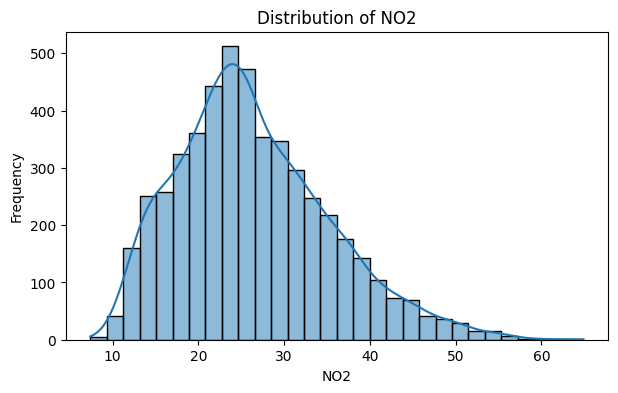

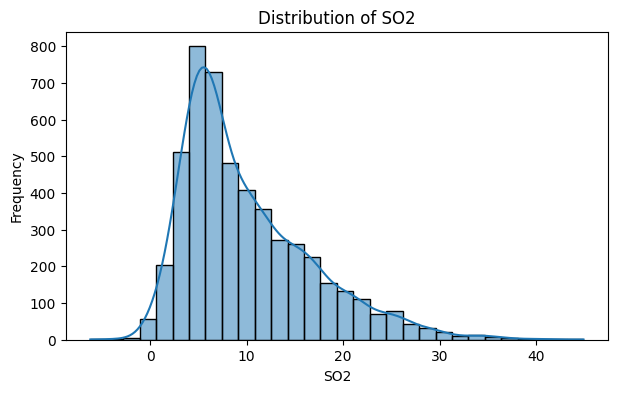

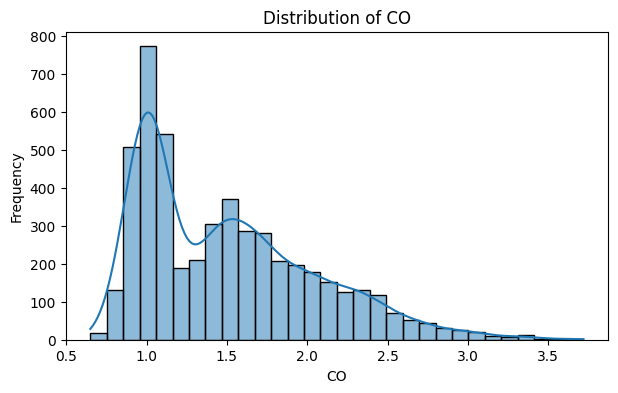

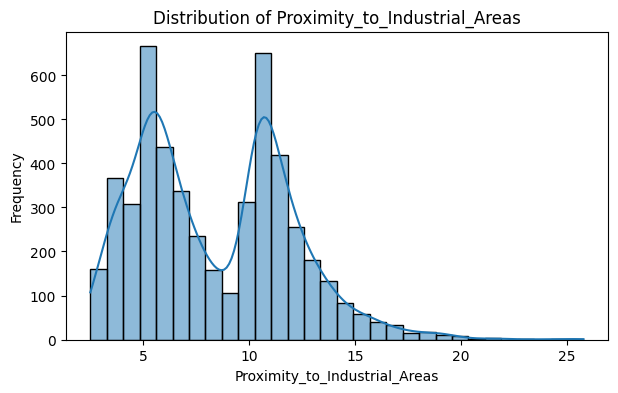

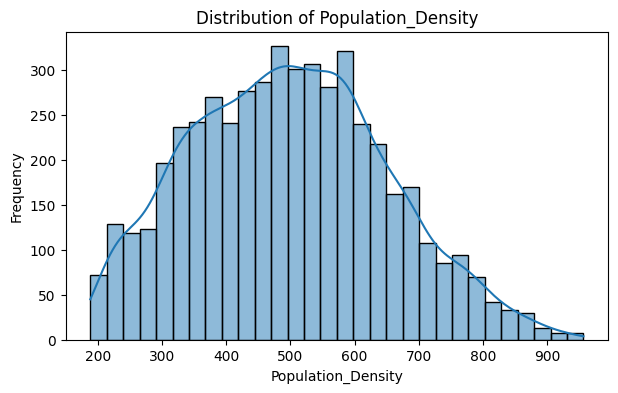

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# 4. Correlation Analysis

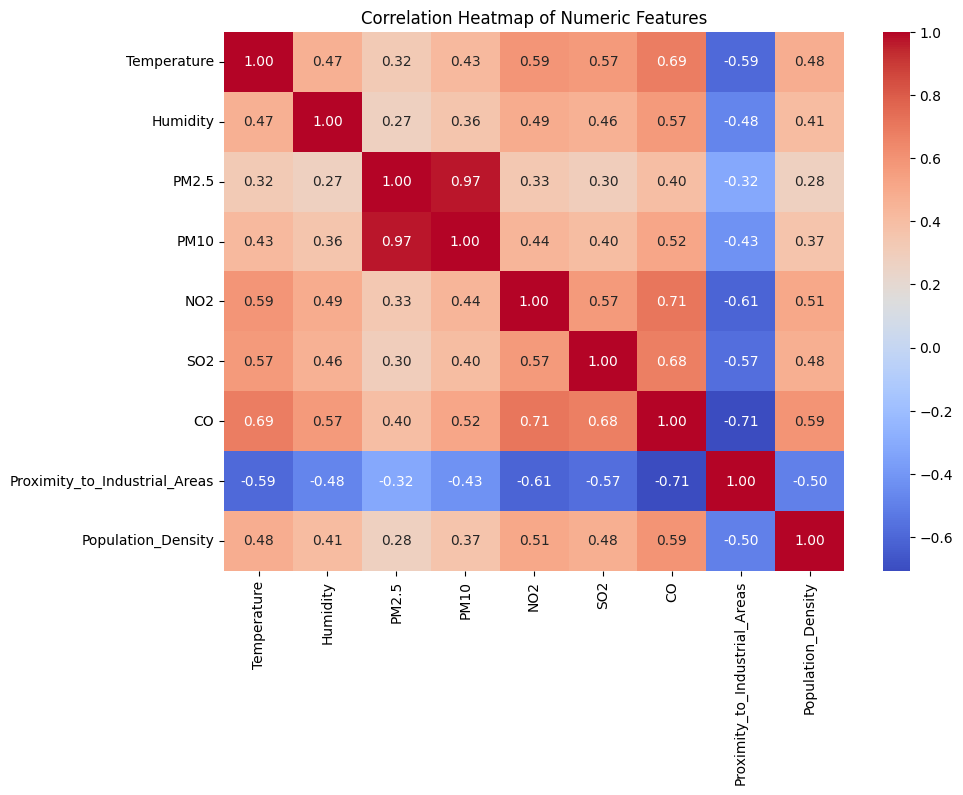

In [15]:
plt.figure(figsize=(10,7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# 5. Pollutants vs Air Quality


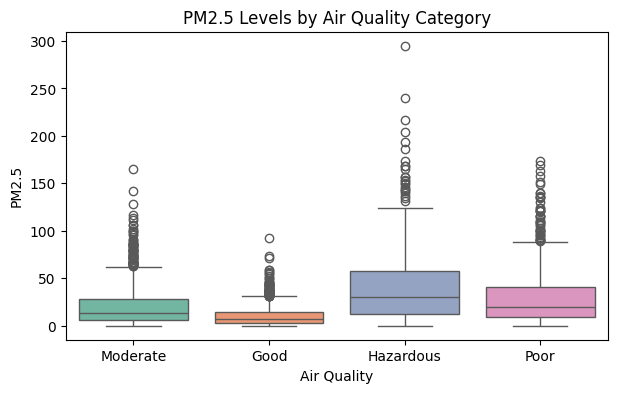

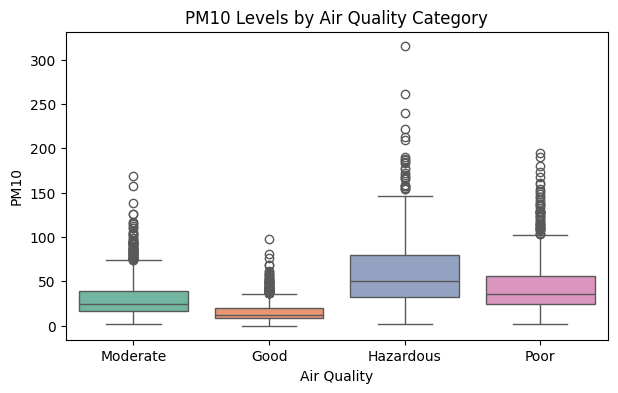

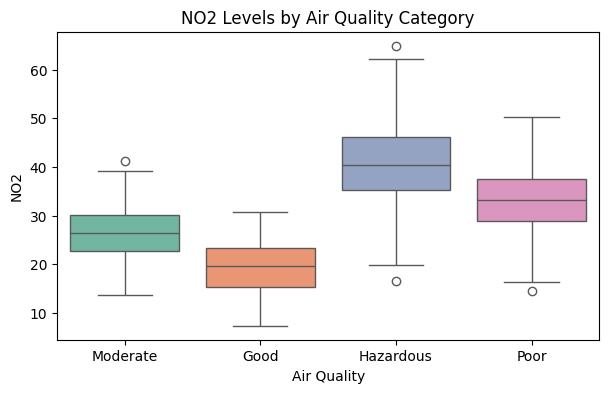

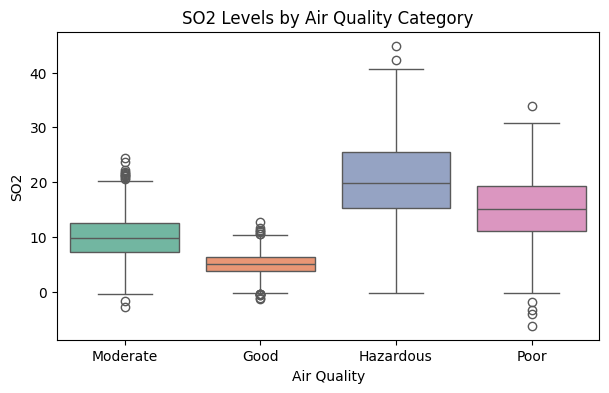

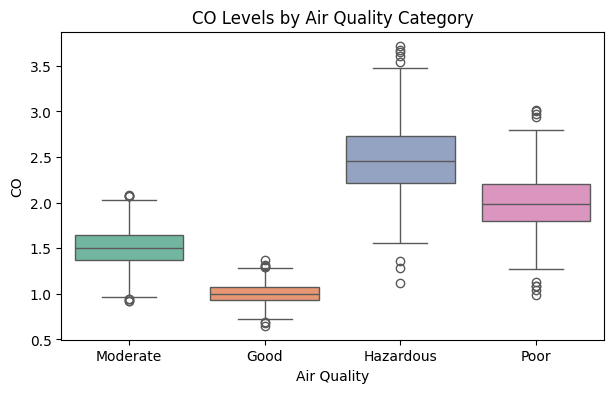

In [16]:
pollutants = ["PM2.5", "PM10", "NO2", "SO2", "CO"]

for col in pollutants:
    plt.figure(figsize=(7,4))
    sns.boxplot(x="Air Quality", y=col, data=df, palette="Set2")
    plt.title(f"{col} Levels by Air Quality Category")
    plt.xlabel("Air Quality")
    plt.ylabel(col)
    plt.show()

# 6. Bivariate Scatterplots


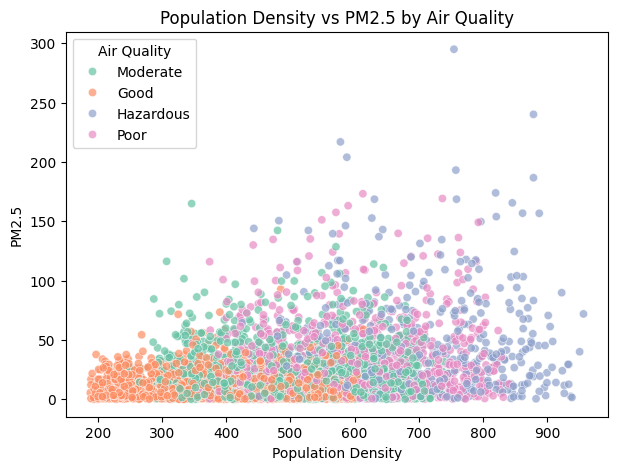

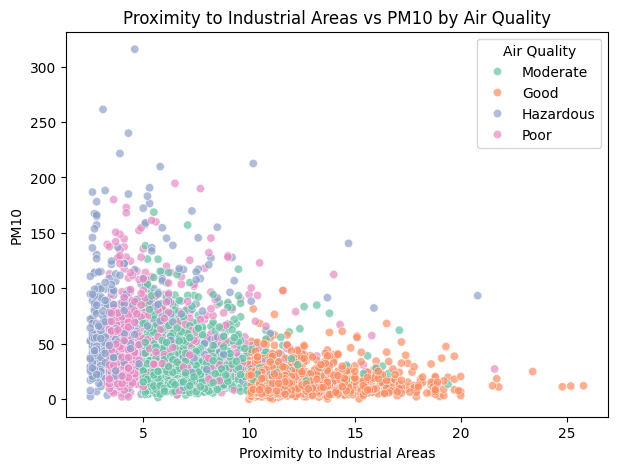

In [17]:

plt.figure(figsize=(7,5))
sns.scatterplot(x="Population_Density", y="PM2.5", hue="Air Quality", data=df, palette="Set2", alpha=0.7)
plt.title("Population Density vs PM2.5 by Air Quality")
plt.xlabel("Population Density")
plt.ylabel("PM2.5")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(x="Proximity_to_Industrial_Areas", y="PM10", hue="Air Quality", data=df, palette="Set2", alpha=0.7)
plt.title("Proximity to Industrial Areas vs PM10 by Air Quality")
plt.xlabel("Proximity to Industrial Areas")
plt.ylabel("PM10")
plt.show()

# 7. Outlier Detection



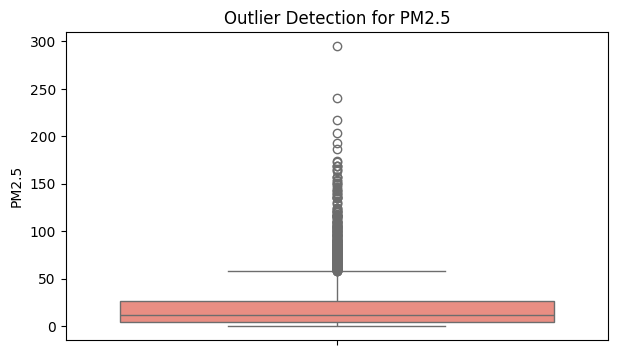

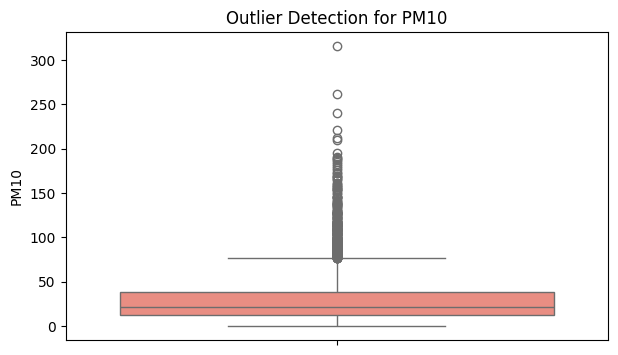

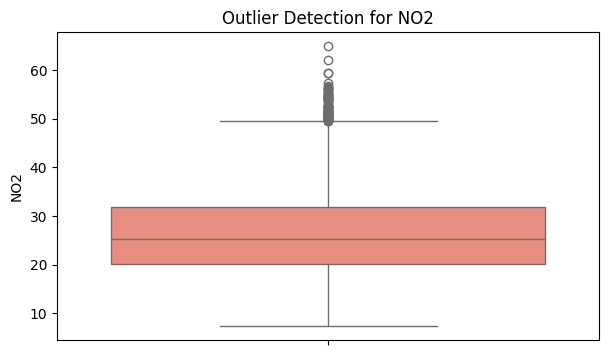

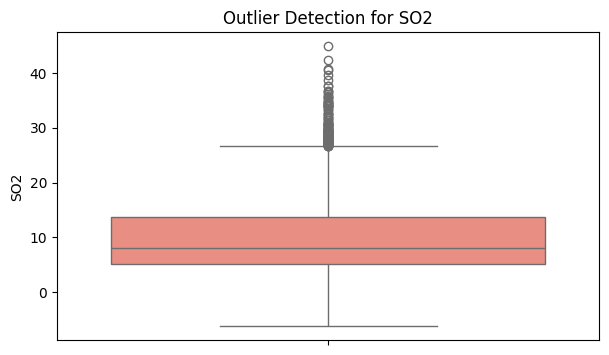

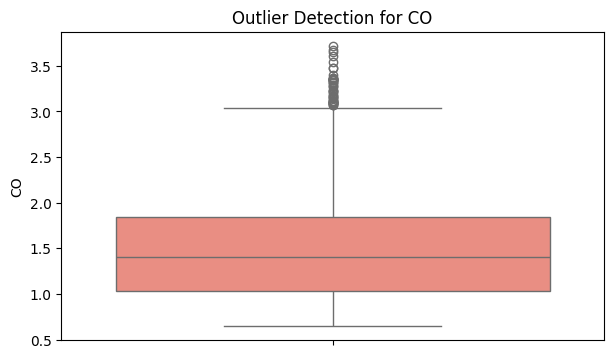

In [18]:
for col in pollutants:
    plt.figure(figsize=(7,4))
    sns.boxplot(y=df[col], color="salmon")
    plt.title(f"Outlier Detection for {col}")
    plt.ylabel(col)
    plt.show()

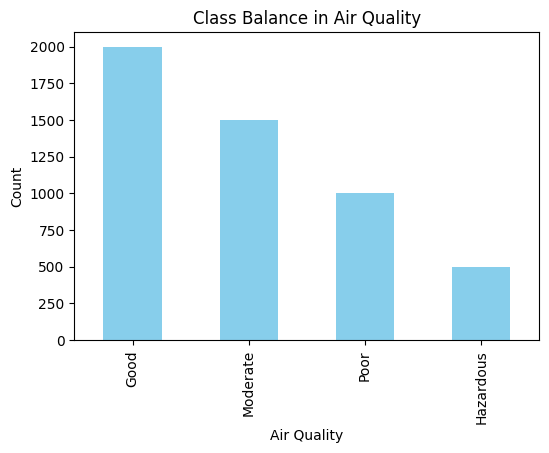

In [19]:
plt.figure(figsize=(6,4))
df["Air Quality"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Class Balance in Air Quality")
plt.xlabel("Air Quality")
plt.ylabel("Count")
plt.show()

## remove the values which are not realistic and negative values


In [20]:
# Remove rows with negative values in numeric columns
df_cleaned = df[(df[numeric_cols] >= 0).all(axis=1)]

# Save cleaned dataset
df_cleaned.to_csv("airpollution_cleaned.csv", index=False)

print("Cleaned dataset saved as airpollution_cleaned.csv")
print("Original shape:", df.shape)
print("Cleaned shape:", df_cleaned.shape)

Cleaned dataset saved as airpollution_cleaned.csv
Original shape: (5000, 10)
Cleaned shape: (4969, 10)
